# Customer Retention Cohort Analysis

This notebook explores customer retention behavior using cohort analysis to uncover actionable insights.


- Measure **retention rates** across customer cohorts  
- Understand **how long customers remain active** after their first purchase  
- Identify **drop-off patterns** over time  
- Translate findings into **business strategies** to improve retention  



## 🛠 Data Preparation

To set up the dataset for cohort analysis, we perform the following steps:

1. **Convert transaction dates to monthly format**  
   - Standardize all purchase dates into `YYYY-MM` format for consistency.  

2. **Assign customer cohorts**  
   - Define each cohort by the **month of first purchase**.  
   - This ensures customers are grouped by their acquisition period.  

3. **Calculate cohort index (time offset)**  
   - Measure the number of months since the first purchase.  
   - This index allows us to track retention behavior across time periods.  

In [2]:
#importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

#loading the dataset

customers = pd.read_csv('../data/raw/customers.csv')
sessions = pd.read_csv('../data/raw/sessions.csv')
cart = pd.read_csv('../data/raw/cart_events.csv')
orders = pd.read_csv('../data/raw/orders.csv')
products = pd.read_csv('../data/raw/products.csv')

In [3]:
# 1. Convert order dates to datetime
orders['order_date'] = pd.to_datetime(orders['order_date'])

# 2. Extract monthly period from order dates (YYYY-MM)
orders['order_month'] = orders['order_date'].dt.to_period('M')

# 3. Assign cohort month (first purchase month per customer)
orders['cohort_month'] = (
    orders.groupby('customer_id')['order_date']
          .transform('min')
          .dt.to_period('M')
)

# 4. Calculate cohort index (months since first purchase)
orders['cohort_index'] = (
    orders['order_month'] - orders['cohort_month']
).apply(lambda x: x.n)

# Cohort Retention Matrix Construction

In [6]:
# --- Cohort Retention Matrix Construction ---

# Step 1: Aggregate unique customers by cohort month and cohort index
cohort_data = (
    orders.groupby(['cohort_month', 'cohort_index'])['customer_id']
          .nunique()
          .reset_index()
)

# Step 2: Pivot the data to create a cohort table
cohort_pivot = cohort_data.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='customer_id'
)

# Step 3: Extract cohort sizes (Month 0 = acquisition month)
cohort_size = cohort_pivot.iloc[:, 0]

# Step 4: Calculate retention matrix
retention = cohort_pivot.divide(cohort_size, axis=0)

# Step 5: Calculate churn matrix (1 - retention)
churn = 1 - retention

# --- Outcome ---
# 'cohort_pivot' → raw counts of active customers by cohort and month index
# 'cohort_size'  → initial cohort sizes (baseline)
# 'retention'    → normalized retention rates (proportion of customers retained)


## 📊 Visualizing Customer Retention

To better understand retention behavior across cohorts, we use a **heatmap visualization**.  
This chart highlights how retention rates evolve over time, making it easy to spot **drop-off patterns** and identify **high-performing cohorts**.  

- **Rows** represent customer cohorts (grouped by first purchase month).  
- **Columns** represent months since acquisition.  
- **Cell values** show retention percentages.  
- **Color intensity** helps quickly identify strong vs. weak retention.  


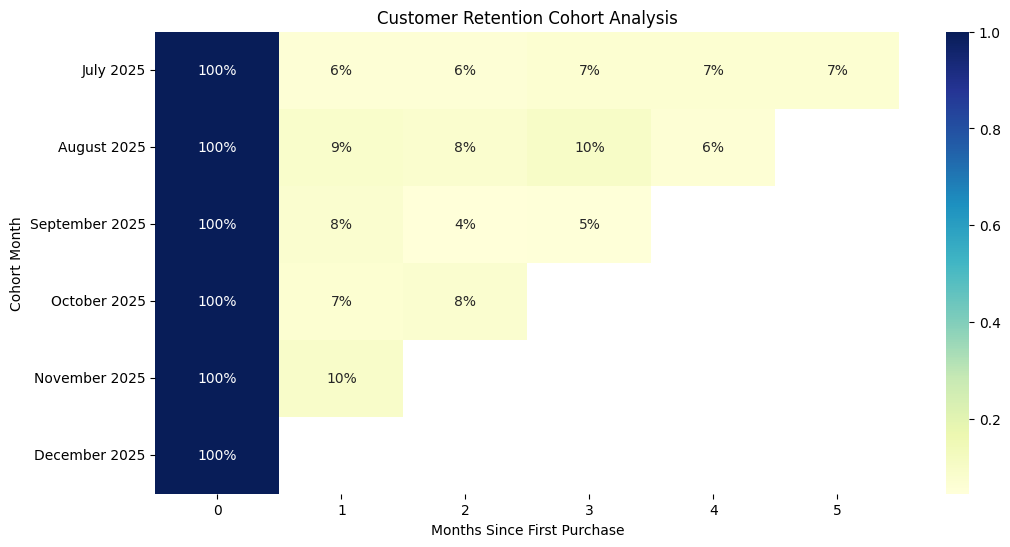

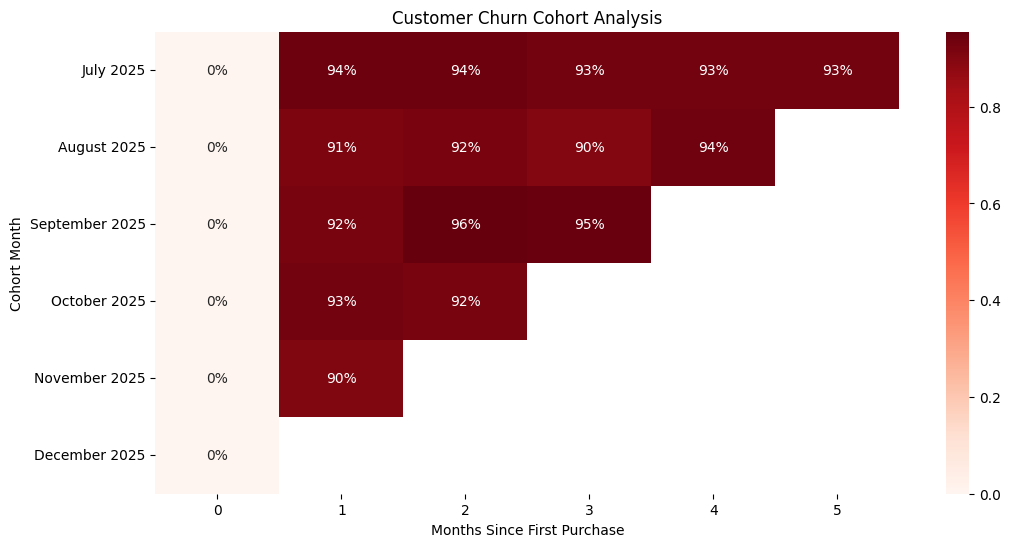

In [7]:
# --------------------------------------------
# Format Cohort Month Labels as Text
# --------------------------------------------

# Convert cohort_month index from Period to string month names (e.g., 'July 2025')
retention.index = retention.index.to_timestamp().strftime('%B %Y')
churn.index = churn.index.to_timestamp().strftime('%B %Y')

# --------------------------------------------
# Retention Heatmap
# --------------------------------------------

plt.figure(figsize=(12,6))
sns.heatmap(retention, annot=True, fmt=".0%", cmap="YlGnBu")
plt.title("Customer Retention Cohort Analysis")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")
plt.show()

# --------------------------------------------
# Churn Heatmap
# --------------------------------------------

plt.figure(figsize=(12,6))
sns.heatmap(churn, annot=True, fmt=".0%", cmap="Reds")
plt.title("Customer Churn Cohort Analysis")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")
plt.show()


## 🔍 Insights
- **Retention drops sharply after Month 1** across all cohorts, with very few customers active beyond Month 3.  
- **July and August cohorts** show slightly stronger retention compared to later months.  
- **Churn rates exceed 90%** by Month 1, confirming early drop-off as the biggest challenge.  
- Repeat purchase behavior exists (~32%), but loyalty is not widespread.  


## 💡 Recommendations
- Strengthen **onboarding and engagement campaigns** in the first 30 days to reduce early churn.  
- Introduce **personalized offers, loyalty rewards, or subscription models** around Month 2–3 to encourage repeat purchases.  
- Analyze **high-retention cohorts (July/August)** to identify successful acquisition or engagement strategies.  
- Segment customers by **channel, product, or geography** to uncover drivers of stronger retention.  


## ✅ Decisions
- Prioritize **early lifecycle interventions** (first 60 days) as the key retention lever.  
- Launch **A/B tests** for engagement nudges (emails, discounts, app notifications) targeting Month 1–2 users.  
- Invest in **loyalty programs** to lift repeat purchase rate beyond 32%.  
- Track retention and churn KPIs as **core metrics** in dashboards to measure strategy impact.  

---

# 📌 Key Retention Metrics

We track the following KPIs to measure customer loyalty and retention performance:

- **Month 1 Retention** → Percentage of users returning within the first month after acquisition.  
- **Month 3 Retention** → Indicator of medium-term engagement and customer stickiness.  
- **Average Retention** → Overall retention rate across cohorts, reflecting long-term performance.  
- **Churn Rate** → Percentage of customers lost over time, highlighting drop-off severity.  
- **Repeat Purchase Rate** → Share of customers making multiple purchases, a direct measure of loyalty. 

In [8]:
# --- Customer Retention KPI Calculation ---

# Month 1 Retention → % of users returning after 1 month
month1_retention = retention[1].mean()

# Month 3 Retention → medium-term retention performance
month3_retention = retention[3].mean()

# Average Retention → overall retention across cohorts
avg_retention = retention.mean().mean()

# Churn Rate → % of customers lost after Month 1
churn_rate = 1 - month1_retention

# Repeat Purchase Rate → % of customers with more than one purchase
repeat_customers = orders.groupby('customer_id')['order_id'].count()
repeat_rate = (repeat_customers > 1).mean()

# Compile KPIs into a summary table
kpi_table = pd.DataFrame({
    "Metric": [
        "Month 1 Retention",
        "Month 3 Retention",
        "Average Retention",
        "Churn Rate",
        "Repeat Purchase Rate"
    ],
    "Value": [
        month1_retention,
        month3_retention,
        avg_retention,
        churn_rate,
        repeat_rate
    ]
})

# Display KPI table
kpi_table.style.format({"Value": "{:.2%}"})


,Metric,Value
0,Month 1 Retention,7.77%
1,Month 3 Retention,7.39%
2,Average Retention,22.56%
3,Churn Rate,92.23%
4,Repeat Purchase Rate,32.25%


## 🔍 Insights
- **Month 1 Retention (7.77%)** → Very low, showing weak onboarding and early engagement.  
- **Month 3 Retention (7.39%)** → Flat compared to Month 1, indicating no long-term stickiness.  
- **Average Retention (22.56%)** → Overall retention is poor, suggesting customers don’t build lasting habits.  
- **Churn Rate (92.23%)** → Extremely high, confirming early drop-off as the biggest challenge.  
- **Repeat Purchase Rate (32.25%)** → One-third of customers return, showing potential for loyalty programs.  


## 💡 Recommendations
- Strengthen **onboarding campaigns** in the first 30 days to reduce early churn.  
- Introduce **personalized offers or loyalty rewards** around Month 2–3 to encourage repeat purchases.  
- Analyze **repeat purchasers** to understand what drives loyalty and replicate those behaviors.  
- Segment cohorts by **channel, product, or geography** to identify stronger vs. weaker retention drivers.  



## ✅ Decisions
- Focus on **early lifecycle interventions** (first 60 days) as the key retention lever.  
- Launch **A/B tests** for engagement nudges (emails, discounts, app notifications) targeting Month 1–2 users.  
- Invest in **loyalty programs** to lift repeat purchase rate beyond 32%.  
- Track these KPIs as **core metrics** in dashboards to measure impact of retention strategies.  

---
